# Notebook 4: Exploratory Data Analysis

## Objective 
The objective of this notebook is to explore the feature-engineered dataset before model development. The analysis assesses the distibutions, temporal patterns, category-level differences, and relationships between exchange-rate movements and food price indicators. The exploratory analysis is intended to identify important patterns, potential anomalies, and relationships that may inform the subsequent econometric and machine learning modelling stages.

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load the dataset
data = pd.read_csv(
    "../data/processed/featured_data.csv",
    parse_dates=["Date"]
)

In [4]:
# view the data
data.head()

,Date,DivisionDescription,GroupDescription,ClassDescription,SubclassDescription,Weight,Eight digit code,CPI,ExchangeRate,Year,...,ExchangeRate_Lag1,ExchangeRate_Lag3,ExchangeRate_Lag6,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3
0,2015-07-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,57.2,12.452687,2015,...,12.303048,12.012553,11.566500,57.0,57.0,0.012163,0.012163,0.000000,12.241892,0.247116
1,2015-08-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.3,12.914595,2015,...,12.452687,11.969940,11.577440,57.2,57.3,0.037093,0.037093,0.000000,12.556777,0.318784
2,2015-09-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,13.610852,2015,...,12.914595,12.303048,12.068727,59.3,57.0,0.053912,0.053912,0.000000,12.992711,0.583021
3,2015-10-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.5,13.504323,2015,...,13.610852,12.452687,12.012553,58.9,57.2,-0.007827,0.000000,0.007827,13.343257,0.375034
4,2015-11-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,14.125733,2015,...,13.504323,12.914595,11.969940,59.5,59.3,0.046016,0.046016,0.000000,13.746969,0.332316


In [5]:
# inspect data
print("Shape:", data.shape)

Shape: (14150, 22)


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14150 entries, 0 to 14149
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 14150 non-null  datetime64[us]
 1   DivisionDescription  14150 non-null  str           
 2   GroupDescription     14150 non-null  str           
 3   ClassDescription     14150 non-null  str           
 4   SubclassDescription  14150 non-null  str           
 5   Weight               14150 non-null  float64       
 6   Eight digit code     14150 non-null  int64         
 7   CPI                  14150 non-null  float64       
 8   ExchangeRate         14150 non-null  float64       
 9   Year                 14150 non-null  int64         
 10  Month                14150 non-null  int64         
 11  Quarter              14150 non-null  int64         
 12  ExchangeRate_Lag1    14150 non-null  float64       
 13  ExchangeRate_Lag3    14150 non-null  float

In [7]:
data.describe()

,Date,Weight,Eight digit code,CPI,ExchangeRate,Year,Month,Quarter,ExchangeRate_Lag1,ExchangeRate_Lag3,ExchangeRate_Lag6,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3
count,14150,14150.000000,1.415000e+04,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000
mean,2020-12-05 13:01:46.346289,0.144390,1.160668e+06,80.513258,15.794418,2020.459293,6.653852,2.550883,15.760464,15.681964,15.547186,80.141845,79.395081,0.002929,0.014649,0.011720,15.758757,0.369359
min,2015-07-01 00:00:00,0.010375,1.111201e+06,40.100000,11.824600,2015.000000,1.000000,1.000000,11.824600,11.824600,11.566500,40.100000,40.100000,-0.074539,0.000000,0.000000,11.915853,0.053243
25%,2018-05-01 00:00:00,0.032154,1.124004e+06,68.100000,14.091309,2018.000000,4.000000,2.000000,14.081841,14.047787,13.923768,67.700000,67.200000,-0.019830,0.000000,0.000000,14.113855,0.200526
50%,2021-01-01 00:00:00,0.089114,1.161201e+06,78.700000,15.215175,2021.000000,7.000000,3.000000,15.146414,15.062438,14.984636,78.200000,77.500000,-0.004332,0.000000,0.004332,15.231720,0.315739
75%,2023-08-01 00:00:00,0.173193,1.186001e+06,95.300000,17.836520,2023.000000,10.000000,4.000000,17.836520,17.836520,17.836520,94.900000,93.900000,0.022168,0.022168,0.019830,17.751849,0.473305
max,2025-12-01 00:00:00,1.447038,1.290001e+06,172.100000,19.065941,2025.000000,12.000000,4.000000,19.065941,19.065941,19.065941,172.100000,172.100000,0.115651,0.115651,0.074539,18.929468,1.784508
std,NaN,0.190869,3.739225e+04,15.720060,2.054620,3.021960,3.437996,1.113747,2.076117,2.117505,2.167035,15.699572,15.626240,0.033929,0.023775,0.015573,2.044655,0.247968


In [8]:
# missing values
missing_values = data.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
# date coverage 
print("Start date:", data["Date"].min())
print("End date:", data["Date"].max())

Start date: 2015-07-01 00:00:00
End date: 2025-12-01 00:00:00


In [10]:
# check observations per year
observations_per_year = (
    data.groupby(data["Date"].dt.year)
    .size()
)

observations_per_year

Date
2015     570
2016    1140
2017    1293
2018    1344
2019    1344
2020    1344
2021    1344
2022    1389
2023    1404
2024    1404
2025    1574
dtype: int64

In [11]:
# check missing values
missing_values = data.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [12]:
# duplicate observations
data.duplicated().sum()

np.int64(0)

In [13]:
data.duplicated(
    subset=["Date", "Eight digit code"]
).sum()

np.int64(0)

In [14]:
# food categories analysis
print("Number of food categories:", data["SubclassDescription"].nunique())

Number of food categories: 49


In [15]:
data["SubclassDescription"].unique()

<StringArray>
[                                                               'Cereals',
                                                       'Flour of cereals',
                                              'Bread and bakery products',
                                                      'Breakfast cereals',
                 'Macaroni, noodles, couscous and similar pasta products',
                                         'Meat, fresh, chilled or frozen',
                               'Meat , dried, salted, in brine or smoked',
                    'Offal, blood and other parts of slaughtered animals',
 'Meat, offal, blood and other parts of slaughtered animals preparations',
                                                                   'Fish',
                                                      'Fish preparations',
                                                          'Other seafood',
                                                                   'Milk',
           

In [16]:
category_counts = (
    data["SubclassDescription"]
    .value_counts()
)

category_counts.head(10)

SubclassDescription
Meat, fresh, chilled or frozen                                            1029
Bread and bakery products                                                  840
Salt, condiments and sauces                                                756
Meat, offal, blood and other parts of slaughtered animals preparations     523
Cheese                                                                     514
Other vegetables, fresh or chilled                                         514
Milk                                                                       504
Fruit-bearing vegetables, fresh or chilled                                 504
Other food products n.e.c.                                                 504
Meat , dried, salted, in brine or smoked                                   378
Name: count, dtype: int64

In [17]:
# EDA Question 1: How did the exchange rate behave during the study period?

monthly_exchange = (
    data[["Date", "ExchangeRate"]]
    .drop_duplicates()
    .sort_values("Date")
)

monthly_exchange.head()

,Date,ExchangeRate
0,2015-07-01,12.452687
1,2015-08-01,12.914595
2,2015-09-01,13.610852
3,2015-10-01,13.504323
4,2015-11-01,14.125733


In [18]:
monthly_exchange.shape

(126, 2)

In [19]:
monthly_exchange["Date"].min(), monthly_exchange["Date"].max()

(Timestamp('2015-07-01 00:00:00'), Timestamp('2025-12-01 00:00:00'))

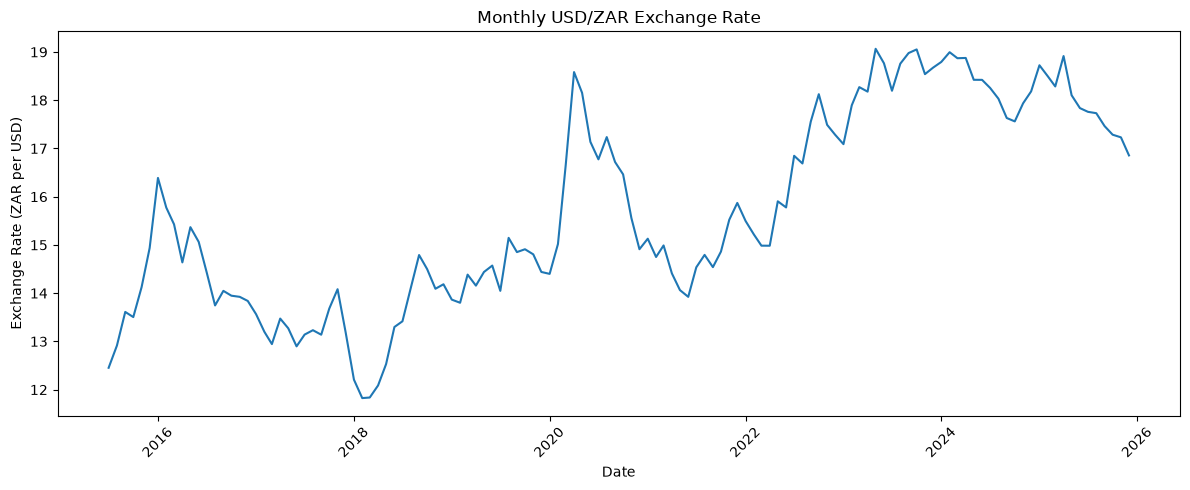

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_exchange["Date"],
    monthly_exchange["ExchangeRate"]
)
plt.title("Monthly USD/ZAR Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate (ZAR per USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Visual and Calculation analysis

The USD/ZAR exchange rate displays substantial fluctuations throughout the study period rather than following a consistently increasing or decreasing trend. The highest observed exchange rate in the feature-engineered dataset occurred in May 2023 at R19.065941 per USD, while the lowest occurred in February 2018 at R11.8246 per USD.

The difference between these values indicates considerable variation in the Rand's value relative to the US Dollar during the study period. Several additional periods of exchange-rate movement are visible in the time-series plot and may need further investigation when interpreting exchange-rate pass-through to food prices.

In [21]:
# calculations
print("Exact date and exchange rate value at maximum:\n",
      monthly_exchange.loc[
     monthly_exchange["ExchangeRate"].idxmax()
])

Exact date and exchange rate value at maximum:
 Date            2023-05-01 00:00:00
ExchangeRate              19.065941
Name: 94, dtype: object


In [22]:
print("Exact date and exchange rate value at minimum:\n",
      monthly_exchange.loc[
          monthly_exchange["ExchangeRate"].idxmin()
      ]
      )

Exact date and exchange rate value at minimum:
 Date            2018-02-01 00:00:00
ExchangeRate                11.8246
Name: 31, dtype: object


In [23]:
#  EDA Question 2: How have food prices changed over the same period?

food_cpi_monthly = (
    data.groupby("Date")["CPI"]
    .mean()
    .reset_index()
)

In [24]:
food_cpi_monthly.head()

,Date,CPI
0,2015-07-01,57.486316
1,2015-08-01,58.254737
2,2015-09-01,58.181053
3,2015-10-01,58.580000
4,2015-11-01,58.867368


In [25]:
food_cpi_monthly.head()

,Date,CPI
0,2015-07-01,57.486316
1,2015-08-01,58.254737
2,2015-09-01,58.181053
3,2015-10-01,58.580000
4,2015-11-01,58.867368


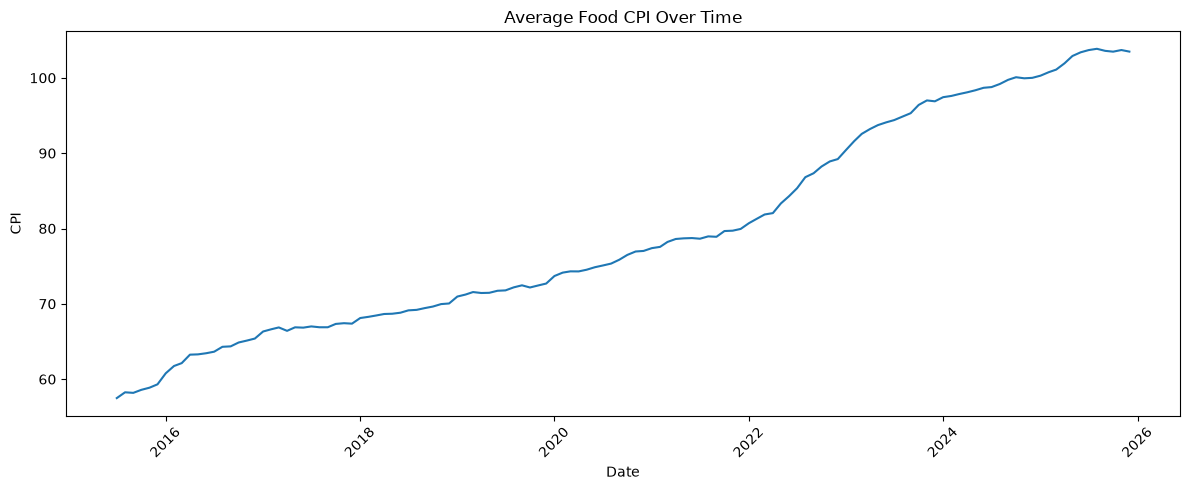

In [26]:
plt.figure(figsize=(12,5))

plt.plot(
    food_cpi_monthly["Date"],
    food_cpi_monthly["CPI"]
)

plt.title("Average Food CPI Over Time")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
# cpi investigation
data[["Date", "SubclassDescription", "CPI"]].head(10)

,Date,SubclassDescription,CPI
0,2015-07-01,Cereals,57.2
1,2015-08-01,Cereals,59.3
2,2015-09-01,Cereals,58.9
3,2015-10-01,Cereals,59.5
4,2015-11-01,Cereals,58.9
5,2015-12-01,Cereals,58.7
6,2016-01-01,Cereals,59.7
7,2016-02-01,Cereals,59.9
8,2016-03-01,Cereals,60.2
9,2016-04-01,Cereals,61.3


In [28]:
category_cpi = (
    data.groupby("SubclassDescription")["CPI"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

category_cpi.head(10)

,mean,min,max
SubclassDescription,,,
Other seafood,107.140000,105.7,108.6
Butter and other fats and oils derived from milk,102.060000,99.2,104.4
"Jams, fruit jellies, marmelades, fruit puree and paste",96.801818,80.7,106.9
"Other fruits, fresh",91.046825,73.6,120.7
"Spices, culinary herbs and seeds",89.483969,57.6,107.2
"Meat, fresh, chilled or frozen",85.935374,56.8,129.4
"Meat, offal, blood and other parts of slaughtered animals preparations",85.813958,60.3,119.4
Baby food,85.813725,61.1,106.3
Flour of cereals,85.346307,56.3,113.1


In [29]:
category_cpi.sort_values("mean").head(10)

,mean,min,max
SubclassDescription,,,
"Dates, figs and tropical fruits, fresh",69.493651,40.1,100.0
Pulses,71.129365,46.4,101.5
Eggs,71.962698,48.8,104.4
"Chocolate, cocoa, and cocoa-based food products",72.133730,45.3,107.5
Tubers,72.451984,44.8,114.9
Sugar,72.855159,42.6,103.7
Other milk and cream,74.540873,48.3,104.9
Water,75.089683,55.1,102.6
"Nut puree, nut butter and nut pastes",75.150000,50.9,101.2


In [30]:
category_cpi.sort_values("mean", ascending=False).head(10)

,mean,min,max
SubclassDescription,,,
Other seafood,107.140000,105.7,108.6
Butter and other fats and oils derived from milk,102.060000,99.2,104.4
"Jams, fruit jellies, marmelades, fruit puree and paste",96.801818,80.7,106.9
"Other fruits, fresh",91.046825,73.6,120.7
"Spices, culinary herbs and seeds",89.483969,57.6,107.2
"Meat, fresh, chilled or frozen",85.935374,56.8,129.4
"Meat, offal, blood and other parts of slaughtered animals preparations",85.813958,60.3,119.4
Baby food,85.813725,61.1,106.3
Flour of cereals,85.346307,56.3,113.1


In [31]:
data["CPI_Change"] = (
    data.groupby("Eight digit code")["CPI"]
    .pct_change()
)

In [32]:
data[["Date", "SubclassDescription", "CPI", "CPI_Change"]].head(15)

,Date,SubclassDescription,CPI,CPI_Change
0,2015-07-01,Cereals,57.2,NaN
1,2015-08-01,Cereals,59.3,0.036713
2,2015-09-01,Cereals,58.9,-0.006745
3,2015-10-01,Cereals,59.5,0.010187
4,2015-11-01,Cereals,58.9,-0.010084
5,2015-12-01,Cereals,58.7,-0.003396
6,2016-01-01,Cereals,59.7,0.017036
7,2016-02-01,Cereals,59.9,0.003350
8,2016-03-01,Cereals,60.2,0.005008
9,2016-04-01,Cereals,61.3,0.018272


In [33]:
data["CPI_Change_Pct"] = data["CPI_Change"] * 100

In [34]:
data[[
    "Date",
    "SubclassDescription",
    "CPI",
    "CPI_Change_Pct"
]].head(15)

,Date,SubclassDescription,CPI,CPI_Change_Pct
0,2015-07-01,Cereals,57.2,NaN
1,2015-08-01,Cereals,59.3,3.671329
2,2015-09-01,Cereals,58.9,-0.674536
3,2015-10-01,Cereals,59.5,1.018676
4,2015-11-01,Cereals,58.9,-1.008403
5,2015-12-01,Cereals,58.7,-0.339559
6,2016-01-01,Cereals,59.7,1.703578
7,2016-02-01,Cereals,59.9,0.335008
8,2016-03-01,Cereals,60.2,0.500835
9,2016-04-01,Cereals,61.3,1.827243


In [35]:
# inspect CPI changes
data["CPI_Change_Pct"].describe()

count    14016.000000
mean         0.505561
std          2.465435
min        -20.660147
25%         -0.408267
50%          0.370828
75%          1.327581
max         32.545455
Name: CPI_Change_Pct, dtype: float64

### CPI Analysis

The average monthly CPI change is approximately 0.51%, while the median is 0.37%. This means that the CPI generally increased from one month to the next across the category-month observations.

In [36]:
# extreme observations
data.loc[
    data["CPI_Change_Pct"].idxmin(),
    ["Date", "SubclassDescription", "CPI", "CPI_Change_Pct"]
]

Date                                          2015-10-01 00:00:00
SubclassDescription    Fruit-bearing vegetables, fresh or chilled
CPI                                                          64.9
CPI_Change_Pct                                         -20.660147
Name: 8140, dtype: object

In [37]:
data.loc[
    data["CPI_Change_Pct"].idxmax(),
    ["Date", "SubclassDescription", "CPI", "CPI_Change_Pct"]
]

Date                                          2016-12-01 00:00:00
SubclassDescription    Leafy or stem vegetables, fresh or chilled
CPI                                                          72.9
CPI_Change_Pct                                          32.545455
Name: 7776, dtype: object

In [38]:
# negative extreme 
data[
    (data["SubclassDescription"] == "Fruit-bearing vegetables, fresh or chilled") &
    (data["Date"].between("2015-08-01", "2015-10-01"))
][[
    "Date",
    "SubclassDescription",
    "CPI",
    "CPI_Change_Pct"
]]

,Date,SubclassDescription,CPI,CPI_Change_Pct
8012,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",54.2,3.041825
8013,2015-09-01,"Fruit-bearing vegetables, fresh or chilled",55.3,2.029520
8014,2015-10-01,"Fruit-bearing vegetables, fresh or chilled",61.9,11.934901
8138,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",81.7,30.720000
8139,2015-09-01,"Fruit-bearing vegetables, fresh or chilled",81.8,0.122399
8140,2015-10-01,"Fruit-bearing vegetables, fresh or chilled",64.9,-20.660147
8264,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",54.9,-2.831858
8265,2015-09-01,"Fruit-bearing vegetables, fresh or chilled",59.4,8.196721
8266,2015-10-01,"Fruit-bearing vegetables, fresh or chilled",63.9,7.575758
8390,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",61.1,6.818182


In [39]:
# positive extreme
data[
    (data["SubclassDescription"] == "Leafy or stem vegetables, fresh or chilled") &
    (data["Date"].between("2016-10-01", "2016-12-01"))
][[
    "Date",
    "SubclassDescription",
    "CPI",
    "CPI_Change_Pct"
]]

,Date,SubclassDescription,CPI,CPI_Change_Pct
7648,2016-10-01,"Leafy or stem vegetables, fresh or chilled",49.9,-1.771654
7649,2016-11-01,"Leafy or stem vegetables, fresh or chilled",50.4,1.002004
7650,2016-12-01,"Leafy or stem vegetables, fresh or chilled",51.6,2.380952
7774,2016-10-01,"Leafy or stem vegetables, fresh or chilled",57.1,-2.559727
7775,2016-11-01,"Leafy or stem vegetables, fresh or chilled",55.0,-3.677758
7776,2016-12-01,"Leafy or stem vegetables, fresh or chilled",72.9,32.545455
7900,2016-10-01,"Leafy or stem vegetables, fresh or chilled",67.0,-1.759531
7901,2016-11-01,"Leafy or stem vegetables, fresh or chilled",68.6,2.388060
7902,2016-12-01,"Leafy or stem vegetables, fresh or chilled",70.3,2.478134


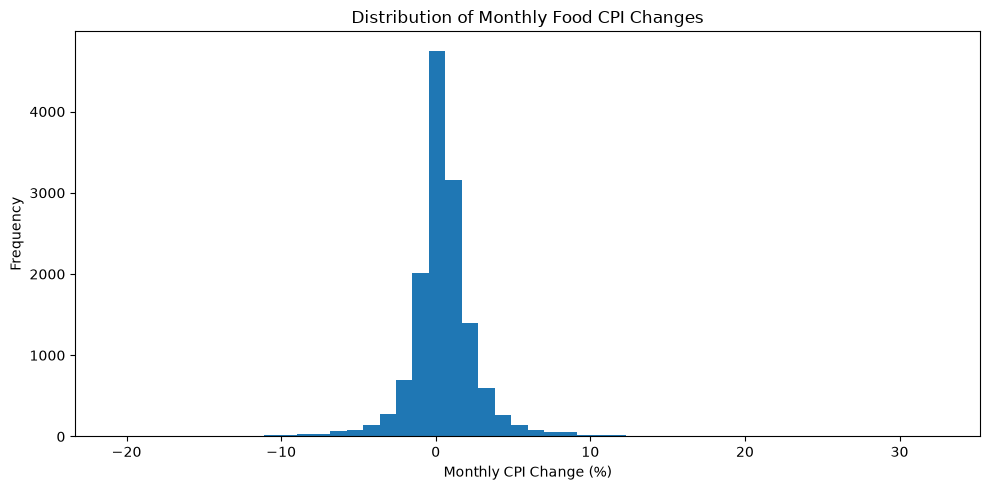

In [ ]:
# EDA Question 3: how are monthly CPI changes distributed across all food items and months?
plt.figure(figsize=(10, 5))

plt.hist(
    data["CPI_Change_Pct"].dropna(),
    bins=50
)

plt.title("Distribution of Monthly Food CPI Changes")
plt.xlabel("Monthly CPI Change (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Distribution of Monthly Food CPI Changes

The distribution of monthly CPI changes is concentrated around relatively small positive and negative changes, with the majority of observations falling within the central range of approximately -12% to 13%. The distribution also contains a small number of observations with substantially larger positive and negative changes, as identified by the minimum and maximum values.

This indicates that while most food-price movements are relatively moderate at the monthly level, certain food items and periods experience considerably larger changes. These observations are retained for further investigation rather than being removed solely because they represent extreme values.

In [43]:
# calculate number of observations that positive, negative or approximately zero
positive_changes = (data["CPI_Change_Pct"] > 0).sum()
negative_changes = (data["CPI_Change_Pct"] < 0).sum()
zero_changes = (data["CPI_Change_Pct"] == 0).sum()

print("Positive changes:", positive_changes)
print("Negative changes:", negative_changes)
print("Zero changes:", zero_changes)

Positive changes: 8463
Negative changes: 4869
Zero changes: 684


In [44]:
# percentage calculations
total_changes = data["CPI_Change_Pct"].notna().sum()
print(
    "Positive:",
    round((positive_changes / total_changes) * 100, 2),
    "%"
)

print(
    "Negative:",
    round((negative_changes / total_changes) * 100, 2),
    "%"
)

print(
    "Zero:",
    round((zero_changes / total_changes) * 100, 2),
    "%"
)

Positive: 60.38 %
Negative: 34.74 %
Zero: 4.88 %


### Calculation Analysis
Out of the 14,016 non-missing category-month CPI changes, 8,463 (60.38%) were positive, 4,869 (34.74%) were negative, and 684 (4.88%) were unchanged.

The higher frequency of positive monthly CPI changes indicates that food-price increases occur more frequently than decreases across the disaggregated observations. This descriptive pattern provides useful context for the subsequent analysis of asymmetric exchange-rate pass-through. However, the frequency of price increases alone does not establish that exchange-rate movements are responsible for these changes. The relationship between exchange-rate movements and food-price changes is examined in subsequent analysis.